### 음성으로 감정 분류하기
1. 데이터 구조
   - 형식: WAV 음성 파일
   - 전체 샘플 수: 2023개
   - 감정별 분포:
     * 분노(Angry): 557개
     * 기쁨(Happy): 500개
     * 중립(Neutral): 399개
     * 슬픔(Sad): 567개

2. 파일명 규칙
   - 형식: [성별]-[감정][번호]-[카테고리]-[ID].wav
   - 예시: M-A3-C-001-0101.wav
     * M: 남성 화자
     * A: 분노 감정 (H: 기쁨, N: 중립, S: 슬픔)
     * 3: 버전 번호
     * C: 카테고리
     * 001-0101: 고유 식별자

3. 분류 클래스
   - 분노, 기쁨, 중립, 슬픔

#### 데이터 전처리
1. 파일명에서 라벨을 추출
2. 음성파일에서 특징을 잡아내는 방법

In [2]:
import os
import librosa
import numpy as np
import pandas as pd

In [3]:
#데이터 파일 경로 설정
data_path = './voice_data/'

file_names=[]

#파일명 리스트에 담기
for i in os.listdir(data_path):
  if i.endswith('.wav'):
    file_names.append(i)

#파일명에서 라벨 추출
def extract_label(file_name):
	parts = file_name.split('-')
	gender = parts[0]
	emotion = parts[1][0]
	unique_code = parts[-1].split('.')[0]
	return gender,emotion,unique_code

# 성별, 감정, 고유식별자 담을 리스트
info_list = []
#파일에서 정보 추출
for file_name in file_names:
	info = extract_label(file_name)
	if info:
			info_list.append(info)

# 데이터셋 생성
data = []
for file in file_names:
    label_info = extract_label(file)  # 성별, 감정, 고유 식별자 추출
    file_path = os.path.join(data_path, file)  # 파일 경로 생성
    data.append({'file_path': file_path, 'Gender': label_info[0], 'Emotion': label_info[1], 'Unique_code': label_info[2]})

#데이터 프레임 생성
df = pd.DataFrame(data)

In [4]:
df.head()

,file_path,Gender,Emotion,Unique_code
0,./voice_data/M-A3-C-001-0101.wav,M,A,0101
1,./voice_data/M-A3-C-001-0102.wav,M,A,0102
2,./voice_data/M-A3-C-001-0103.wav,M,A,0103
3,./voice_data/M-A3-C-001-0104.wav,M,A,0104
4,./voice_data/M-A3-C-001-0105.wav,M,A,0105


In [5]:
#Emotion 매핑해주기

emotion_map = {'A':'Angry', 'H':'Happy','N':'Nutral','S':'Sad'}

df['Emotion'] = df['Emotion'].map(emotion_map)

df.head()

,file_path,Gender,Emotion,Unique_code
0,./voice_data/M-A3-C-001-0101.wav,M,Angry,0101
1,./voice_data/M-A3-C-001-0102.wav,M,Angry,0102
2,./voice_data/M-A3-C-001-0103.wav,M,Angry,0103
3,./voice_data/M-A3-C-001-0104.wav,M,Angry,0104
4,./voice_data/M-A3-C-001-0105.wav,M,Angry,0105


### 시각화를 위한 데이터 추출 및 데이터프레임화 완료
1. info()로 데이터 확인
2. 시각화

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2023 entries, 0 to 2022
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   file_path    2023 non-null   object
 1   Gender       2023 non-null   object
 2   Emotion      2023 non-null   object
 3   Unique_code  2023 non-null   object
dtypes: object(4)
memory usage: 63.3+ KB


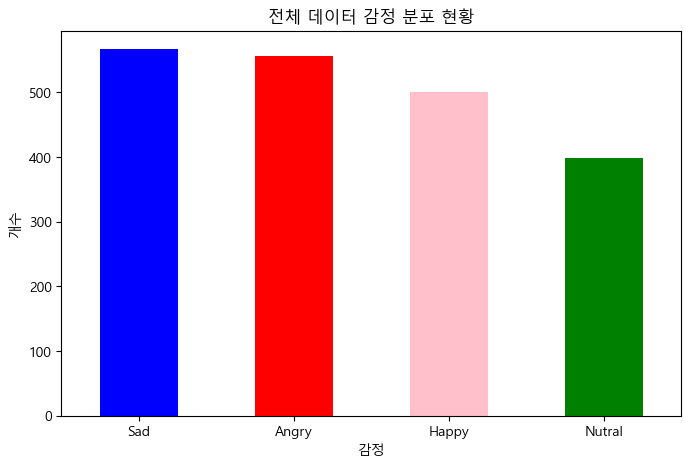

In [7]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False


# 전체 감정 분포 계산
emotion_distribution = df['Emotion'].value_counts()

# 전체 감정 분포 시각화
plt.figure(figsize=(8, 5))
emotion_distribution.plot(kind='bar', color=['blue', 'red', 'pink', 'green'])
plt.title('전체 데이터 감정 분포 현황')
plt.xlabel('감정')
plt.ylabel('개수')
plt.xticks(rotation=0)
plt.show()

In [8]:
df['Emotion'].value_counts()

Emotion
Sad       567
Angry     557
Happy     500
Nutral    399
Name: count, dtype: int64

In [9]:
df['Gender'].value_counts()

Gender
M    2023
Name: count, dtype: int64

#### 전체 데이터가 남성이라서 성별에 따른 데이터 분포 시각화는 생략

#### 음성 데이터 시각화 librosa

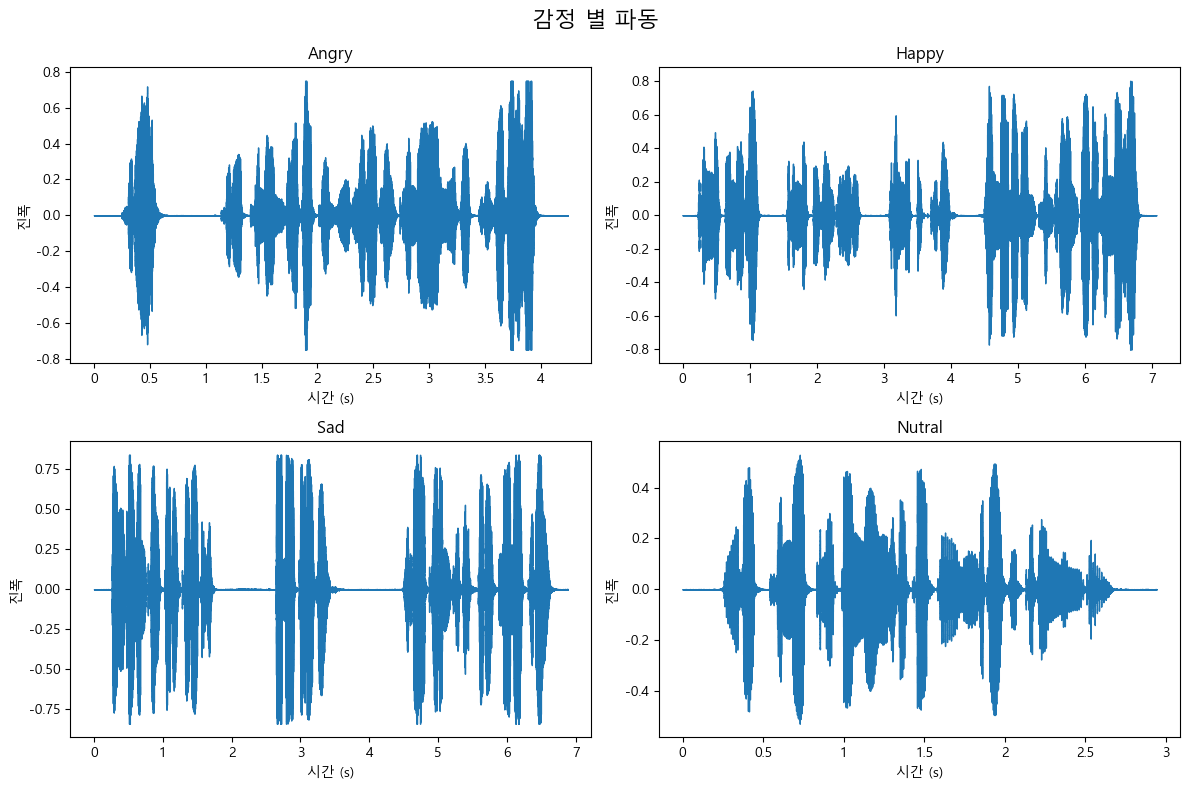

In [10]:
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt

# 시각화를 위한 감정 별 음성 파일 로드
file_paths = {'Angry':'./voice_data/M-A3-C-001-0101.wav',
              'Happy':'./voice_data/M-H3-C-001-0101.wav',
              'Sad':'./voice_data/M-S3-C-001-0101.wav',
              'Nutral':'./voice_data/M-NX-C-001-0101.wav'
              }

# 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('감정 별 파동', fontsize=16)

# 감정별 음성 파형 그리기

for ax, (emotion, file_path) in zip(axes.flatten(), file_paths.items()):  
    # 음성 파일 로드
    try:
        data,sr = sf.read(file_path)
        librosa.display.waveshow(data, sr=sr, ax=ax)
        # y, sr = librosa.load(file_path)
        # librosa.display.waveshow(y, sr=sr, ax=ax)
        ax.set_title(emotion)
        ax.set_xlabel('시간 (s)')
        ax.set_ylabel('진폭')
    except FileNotFoundError:
        ax.set_title(f"{emotion} (File Not Found)")
        ax.axis('off')

# 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

### 트러블 슈팅
> OSError: cannot load library 'libsndfile.dll': error 0x7e

libsndfile.dll은 soundfile의 핵심 의존성이다.

```
pip uninstall soundfile
pip install soundfile
```

으로 제거 후 재 설치해주면 문제없이 실행됐다.

In [11]:
# 음성 데이터 전처리
# 음성의 진폭(높낮이)로 감정을 판단하는 기준이 될것이기에 진폭을 피처로 잡고 정규화
def preprocess_audio(file_path):
    audio, rs= librosa.load(file_path)
    audio = librosa.util.normalize(audio)
    return audio

df['audio'] = df['file_path'].apply(preprocess_audio)

In [12]:
# 음성 데이터에서 특성(MFCC) 추출
# MFCC - MFCC는 인간의 청각 시스템을 모방하여 음성 신호를 분석하는 특징

def extract_features(audio, sr=22050):
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)  # 40개의 MFCC 계수 추출
    return np.mean(mfccs.T, axis=0)  # 시간 축에 대해 평균값 계산

# 데이터프레임에 MFCC 특징 추가
df['features'] = df['audio'].apply(lambda x: extract_features(x))

In [13]:
#특징 벡터를 배열로
X = np.array(df['features'].tolist())  # 모든 특징 벡터를 NumPy 배열로 변환
y = np.array(df['Emotion'].tolist())  # 감정 라벨을 NumPy 배열로 변환

In [14]:
df.head()

,file_path,Gender,Emotion,Unique_code,audio,features
0,./voice_data/M-A3-C-001-0101.wav,M,Angry,0101,"[-0.00021118009, -0.00030441876, -0.0002725991...","[-259.16553, 79.87538, -13.504722, 32.225597, ..."
1,./voice_data/M-A3-C-001-0102.wav,M,Angry,0102,"[0.00027067616, 0.00041243053, 0.00038960917, ...","[-230.00215, 75.2523, -20.765657, 26.700716, -..."
2,./voice_data/M-A3-C-001-0103.wav,M,Angry,0103,"[4.0292136e-05, 1.5881948e-05, -4.9988994e-06,...","[-229.77158, 61.946407, -15.388544, 28.594303,..."
3,./voice_data/M-A3-C-001-0104.wav,M,Angry,0104,"[-9.781569e-05, -6.553976e-05, -8.949262e-05, ...","[-263.54797, 87.73107, -18.438654, 16.107677, ..."
4,./voice_data/M-A3-C-001-0105.wav,M,Angry,0105,"[-8.666776e-05, -0.00013490638, -0.00011120766...","[-252.54028, 82.877716, -17.478388, 24.008684,..."


### 라벨 인코딩

In [15]:
from sklearn.preprocessing import LabelEncoder

# 라벨 인코딩
encoder = LabelEncoder()
df['encoded_emotion'] = encoder.fit_transform(df['Emotion'])


# 인코딩 결과 확인
df.head()

,file_path,Gender,Emotion,Unique_code,audio,features,encoded_emotion
0,./voice_data/M-A3-C-001-0101.wav,M,Angry,0101,"[-0.00021118009, -0.00030441876, -0.0002725991...","[-259.16553, 79.87538, -13.504722, 32.225597, ...",0
1,./voice_data/M-A3-C-001-0102.wav,M,Angry,0102,"[0.00027067616, 0.00041243053, 0.00038960917, ...","[-230.00215, 75.2523, -20.765657, 26.700716, -...",0
2,./voice_data/M-A3-C-001-0103.wav,M,Angry,0103,"[4.0292136e-05, 1.5881948e-05, -4.9988994e-06,...","[-229.77158, 61.946407, -15.388544, 28.594303,...",0
3,./voice_data/M-A3-C-001-0104.wav,M,Angry,0104,"[-9.781569e-05, -6.553976e-05, -8.949262e-05, ...","[-263.54797, 87.73107, -18.438654, 16.107677, ...",0
4,./voice_data/M-A3-C-001-0105.wav,M,Angry,0105,"[-8.666776e-05, -0.00013490638, -0.00011120766...","[-252.54028, 82.877716, -17.478388, 24.008684,...",0


In [16]:
from sklearn.model_selection import train_test_split

# 학습 데이터와 테스트 데이터 분할 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, df['encoded_emotion'], test_size=0.2, random_state=22)

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 신경망 모델 설계
model = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),  # 입력 크기: 특징 벡터 크기 (n_mfcc=40)
    Dropout(0.3),  # 과적합 방지용 드롭아웃
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(encoder.classes_), activation='softmax')  # 출력 크기: 클래스 수 (4개 감정)
])

# 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [46]:
# 모델 학습
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/30
51/51 [==============================] - 1s 6ms/step - loss: 10.0285 - accuracy: 0.3473 - val_loss: 0.6554 - val_accuracy: 0.7827
Epoch 2/30
51/51 [==============================] - 0s 2ms/step - loss: 2.5570 - accuracy: 0.4524 - val_loss: 0.9002 - val_accuracy: 0.7457
Epoch 3/30
51/51 [==============================] - 0s 2ms/step - loss: 1.4212 - accuracy: 0.5124 - val_loss: 0.9039 - val_accuracy: 0.8370
Epoch 4/30
51/51 [==============================] - 0s 2ms/step - loss: 1.1296 - accuracy: 0.5785 - val_loss: 0.7067 - val_accuracy: 0.8519
Epoch 5/30
51/51 [==============================] - 0s 2ms/step - loss: 0.9218 - accuracy: 0.6267 - val_loss: 0.4398 - val_accuracy: 0.9136
Epoch 6/30
51/51 [==============================] - 0s 2ms/step - loss: 0.7378 - accuracy: 0.6842 - val_loss: 0.3447 - val_accuracy: 0.9284
Epoch 7/30
51/51 [==============================] - 0s 2ms/step - loss: 0.6270 - accuracy: 0.7423 - val_loss: 0.2763 - val_accuracy: 0.9333
Epoch 8/30
51/51 [=

In [47]:
# 모델 평가
evaluation = model.evaluate(X_test, y_test)
print("Test Loss:", evaluation[0])
print("Test Accuracy:", evaluation[1])

13/13 [==============================] - 0s 877us/step - loss: 0.0160 - accuracy: 0.9951
Test Loss: 0.01595929265022278
Test Accuracy: 0.9950617551803589


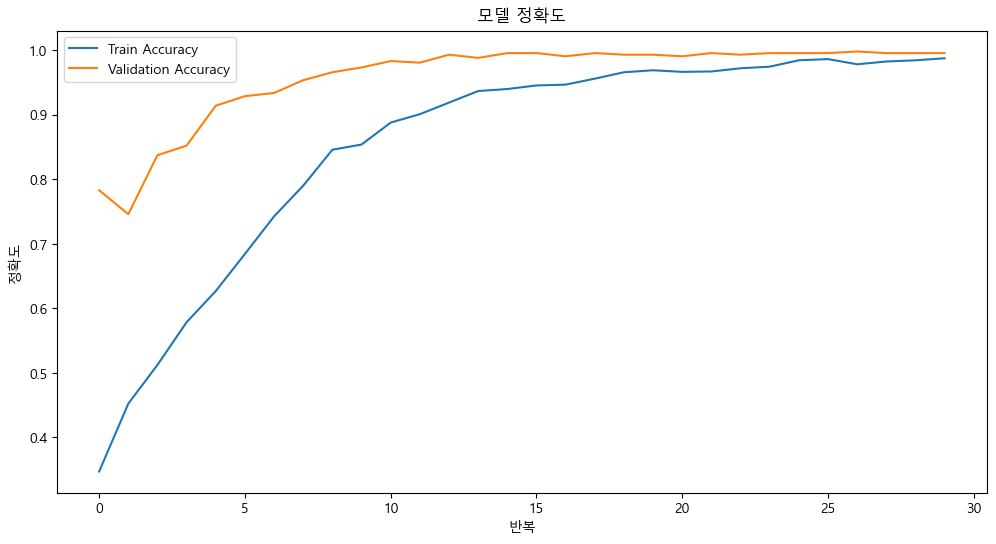

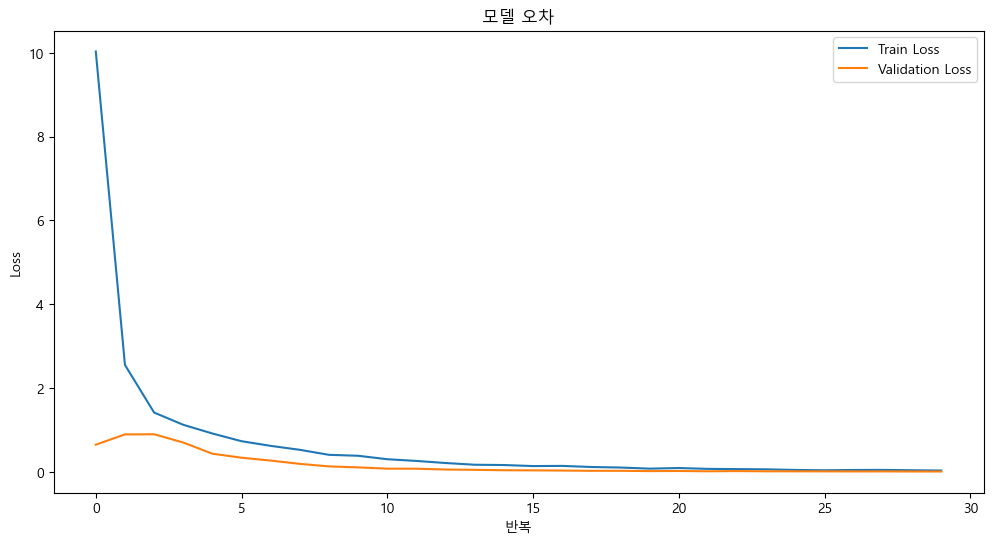

In [48]:
import matplotlib.pyplot as plt

# 정확도 시각화
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('모델 정확도')
plt.xlabel('반복')
plt.ylabel('정확도')
plt.legend()
plt.show()

# 손실 시각화
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('모델 오차')
plt.xlabel('반복')
plt.ylabel('Loss')
plt.legend()
plt.show()


### 새로운 음성파일로 테스트 해보자!

In [50]:
# 새로운 음성 파일 경로 설정
new_audio_path = './voice_data/M-H3-C-001-0101.wav'

# 음성 데이터 전처리
def preprocess_audio(file_path):
    audio, sr = librosa.load(file_path, sr=22050)
    audio = librosa.util.normalize(audio)
    return audio

new_audio = preprocess_audio(new_audio_path)

# 특징 추출
def extract_features(audio, sr=22050):
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    return np.mean(mfccs.T, axis=0)

new_features = extract_features(new_audio)

# 입력 형태 변환 및 예측 수행
new_features = np.expand_dims(new_features, axis=0)
predicted_class = model.predict(new_features)
predicted_label = encoder.inverse_transform([np.argmax(predicted_class)])

print(f"Predicted Emotion: {predicted_label[0]}")

1/1 [==============================] - 0s 15ms/step
Predicted Emotion: Happy


### 음성을 텍스트로 변환해서 예측해보면 어떨까?

In [ ]:
#오디오 파일을 텍스트로
import os
import pandas as pd
import speech_recognition as sr
from pydub import AudioSegment
from pydub.silence import split_on_silence
from joblib import Parallel, delayed
import subprocess


# FFmpeg를 사용하여 오디오 파일을 PCM WAV로 변환하는 함수
def convert_audio(input_path, output_path):
		"""
		Converts an audio file to PCM WAV format using FFmpeg.
		
		Parameters:
				input_path (str): Path to the input audio file.
				output_path (str): Path to save the converted audio file.
		"""
		command = f"ffmpeg -i {input_path} -ac 1 -ar 16000 -sample_fmt s16 {output_path}"
		os.system(command)


# FFmpeg를 사용하여 오디오 청크를 저장하는 함수
def export_with_ffmpeg(input_audio_path, output_audio_path):
    """
    Exports audio chunk using FFmpeg command directly.
    
    Parameters:
        input_audio_path (str): Path to the input audio file.
        output_audio_path (str): Path to save the exported audio chunk.
    """
    command = [
        "ffmpeg",
        "-y",  # 기존 파일 덮어쓰기
        "-i", input_audio_path,
        output_audio_path,
    ]
    try:
        print(f"FFmpeg 진행중: {' '.join(command)}")
        subprocess.run(command, check=True)
        print(f"FFmpeg 출력 성공: {output_audio_path}")
    except subprocess.CalledProcessError as e:
        raise Exception(f"FFmpeg export failed: {e}")


def audio_to_text(file_path):
	print(f"파일 처리 시작: {os.path.basename(file_path)}")
	#음성인식 모듈 객체화(초기화)
	recognizer = sr.Recognizer()

	try:
		#오디오 파일 로드
		audio = AudioSegment.from_wav(file_path)
		audio = audio.normalize() #오디오 진폭 정규화
		audio += 6 #6db증폭(작은 소리를 더 잘 잡아서 인식률 높이기 위해)

		#오디오 파일을 일정할 길이로 조각화
		chunks = split_on_silence(
				audio,
				min_silence_len=500,     #최소 침묵 길이 (500ms)
				silence_thresh= -30,     #침묵 임계값
				keep_silence= 250        #각 조각의 앞뒤에 남겨둘 침묵 길이 
		)
		print(f"파일 '{os.path.basename(file_path)}'을 {len(chunks)}개 청크로 분할했습니다.")


		# 짧은 청크 필터링 
		filtered_chunks = [chunk for chunk in chunks if len(chunk) > 1000]  # 길이가 1초 이상인 청크만 사용

		#각 조각들에 대한 음성 인식 수행
		full_text = ""
		for i, chunk in enumerate(filtered_chunks):
			print(f"청크 {i+1}/{len(filtered_chunks)} 처리 중...")
			
			#10ms의 침묵 추가
			print('침묵 추가 로직 진행중...')
			chunk_silence = AudioSegment.silent(duration=50)
			audio_chunk = chunk_silence + chunk + chunk_silence
			if len(audio_chunk) == 0:
				raise Exception("오디오 청크가 비어 있습니다.")

			# 임시 분할 파일 저장
			temp_chunk_path = f'temp_chunk_{i}_original.wav'
			temp_file = f'temp_chunk_{i}.wav'

			try:
				# 임시 파일 저장 (FFmpeg로 대체)
				audio_chunk.export(temp_chunk_path, format='wav')  # 원본 청크 저장
				export_with_ffmpeg(temp_chunk_path, temp_file)
				
				#음성 인식 수행
				print('음성 인식 수행 시작...')
				with sr.AudioFile(temp_file) as source:
						recognizer.adjust_for_ambient_noise(source, duration=1) #소음 조정 시간 증가
						audio_data = recognizer.record(source)

						#음성인식 재시도 로직
						success = False
						retry_count = 3
						for attempt in range(retry_count):
								try:
										#한국어 인식 설정
										text = recognizer.recognize_google(audio_data, language='ko-KR')
										full_text += text + " " 
										success = True
										print(f"청크 {i+1} 인식 성공: {text}")
										break
								except sr.UnknownValueError:
										print(f'오디오를 인식할 수 없습니다: 청크 {i+1}')
										break
								except sr.RequestError as e:
										print(f'Google Web Speech API 요청 중 오류 발생 (재시도 {attempt+1}/{retry_count}): {e}')
		
						if not success:
								print(f'오디오 청크 {i+1} 변환 실패')
			finally:	
				# 임시 파일 정리
				if os.path.exists(temp_file):
						os.remove(temp_file)
				if os.path.exists(temp_file):
						os.remove(temp_file)
		
		print(f"파일 처리 완료: {os.path.basename(file_path)}")
		print(f"변환된 텍스트: {full_text}")
		return full_text

	except Exception as e:
			print(f"파일 '{os.path.basename(file_path)}' 처리 중 오류 발생: {e}")
			return None

In [ ]:
#음성 파일 경로
wav_path = './voice_data'

#음성 파일 가지고 오기
file_names = [f for f in os.listdir(wav_path) if f.endswith('.wav')]
file_paths = [os.path.join(wav_path, f) for f in file_names]

# 디버깅용 메시지 추가
print(f"처리할 파일 수: {len(file_paths)}")

#디버깅을 위한 직렬화
result = [audio_to_text(file_path) for file_path in file_paths]

#텍스트 변환 내용 저장
df['voice_to_text'] = result

#데이터 프레임 저장
try :
	df.to_csv('processed_voice_data_to_text.csv', index=False, encoding='utf-8-sig')
except Exception as e:
	print(e)
print('CSV파일 저장 완료')	

#총 시간 68m

처리할 파일 수: 2023
파일 처리 시작: M-A3-C-001-0101.wav
파일 'M-A3-C-001-0101.wav'을 2개 청크로 분할했습니다.
청크 1/1 처리 중...
침묵 추가 로직 진행중...
FFmpeg 진행중: ffmpeg -y -i temp_chunk_0_original.wav temp_chunk_0.wav
FFmpeg 출력 성공: temp_chunk_0.wav
음성 인식 수행 시작...
청크 1 인식 성공: 네가 더 못 이뤄질 테니 어디 두고 봐라
파일 처리 완료: M-A3-C-001-0101.wav
변환된 텍스트: 네가 더 못 이뤄질 테니 어디 두고 봐라 
파일 처리 시작: M-A3-C-001-0102.wav
파일 'M-A3-C-001-0102.wav'을 1개 청크로 분할했습니다.
청크 1/1 처리 중...
침묵 추가 로직 진행중...
FFmpeg 진행중: ffmpeg -y -i temp_chunk_0_original.wav temp_chunk_0.wav
FFmpeg 출력 성공: temp_chunk_0.wav
음성 인식 수행 시작...
청크 1 인식 성공: 내 거라는 걸 알았으니 그걸 견딜 수가 없어
파일 처리 완료: M-A3-C-001-0102.wav
변환된 텍스트: 내 거라는 걸 알았으니 그걸 견딜 수가 없어 
파일 처리 시작: M-A3-C-001-0103.wav
파일 'M-A3-C-001-0103.wav'을 1개 청크로 분할했습니다.
청크 1/1 처리 중...
침묵 추가 로직 진행중...
FFmpeg 진행중: ffmpeg -y -i temp_chunk_0_original.wav temp_chunk_0.wav
FFmpeg 출력 성공: temp_chunk_0.wav
음성 인식 수행 시작...
청크 1 인식 성공: 죽인 거지
파일 처리 완료: M-A3-C-001-0103.wav
변환된 텍스트: 죽인 거지 
파일 처리 시작: M-A3-C-001-0104.wav
파일 'M-A3-C-001-0104.wav'을 2개 청크로 분할했습니다.
청크

### 병렬화 처리를 통해서 시간 단축

In [ ]:
import os
import uuid
import pandas as pd
import speech_recognition as sr
from pydub import AudioSegment
from pydub.silence import split_on_silence
from joblib import Parallel, delayed

# FFmpeg를 사용하여 오디오 청크를 저장하는 함수
def export_with_ffmpeg(input_audio_path, output_audio_path):
    command = [
        "ffmpeg",
        "-y",  # 기존 파일 덮어쓰기
        "-i", input_audio_path,
        output_audio_path,
    ]
    try:
        subprocess.run(command, check=True)
    except subprocess.CalledProcessError as e:
        raise Exception(f"FFmpeg export failed: {e}")

# 음성 파일 텍스트 변환 함수
def audio_to_text(file_path):
    print(f"파일 처리 시작: {os.path.basename(file_path)}")
    recognizer = sr.Recognizer()

    try:
        # 오디오 파일 로드 및 정규화
        audio = AudioSegment.from_wav(file_path).normalize() + 6

        # 오디오를 청크로 분할
        chunks = split_on_silence(
            audio,
            min_silence_len=500,
            silence_thresh=-30,
            keep_silence=250,
        )
        print(f"파일 '{os.path.basename(file_path)}'을 {len(chunks)}개 청크로 분할했습니다.")

        full_text = ""
        for i, chunk in enumerate(chunks):
            print(f"청크 {i+1}/{len(chunks)} 처리 중...")

            # 고유한 임시 파일 이름 생성
            temp_chunk_path = f'temp_chunk_{i}_{uuid.uuid4().hex}_original.wav'
            temp_file = f'temp_chunk_{i}_{uuid.uuid4().hex}.wav'

            try:
                # 청크를 임시 파일로 저장
                chunk.export(temp_chunk_path, format='wav')
                export_with_ffmpeg(temp_chunk_path, temp_file)

                # 음성 인식 수행
                with sr.AudioFile(temp_file) as source:
                    recognizer.adjust_for_ambient_noise(source, duration=1)
                    audio_data = recognizer.record(source)
                    text = recognizer.recognize_google(audio_data, language='ko-KR')
                    full_text += text + " "
                    print(f"청크 {i+1} 인식 성공: {text}")

            except Exception as e:
                print(f"청크 {i+1} 처리 중 오류 발생: {e}")

            finally:
                # 임시 파일 삭제
                if os.path.exists(temp_chunk_path):
                    os.remove(temp_chunk_path)
                if os.path.exists(temp_file):
                    os.remove(temp_file)

        return full_text.strip()

    except Exception as e:
        print(f"파일 '{file_path}' 처리 중 오류 발생: {e}")
        return None

# 음성 파일 경로 설정 및 병렬 처리 실행
wav_path = './voice_data'
file_names = [f for f in os.listdir(wav_path) if f.endswith('.wav')]
file_paths = [os.path.join(wav_path, f) for f in file_names]

print(f"처리할 파일 수: {len(file_paths)}")

# 병렬 처리 실행
result = Parallel(n_jobs=-1, verbose=10)(delayed(audio_to_text)(file_path) for file_path in file_paths)

# 결과 저장
df['voice_to_text'] = result

try:
    df.to_csv('parallel_processed_voice_data_to_text.csv', index=False, encoding='utf-8-sig')
    print('CSV 파일 저장 완료')
except Exception as e:
    print(f"CSV 저장 중 오류 발생: {e}")
    
## 소요시간 3m


처리할 파일 수: 2023


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done  50 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done  80 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:   11.1s
[Parallel(n_jobs=-1)]: Done 133 tasks      | elapsed:   12.2s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done 173 tasks      | elapsed:   15.7s
[Parallel(n_jobs=-1)]: Done 194 tasks      | elapsed:   17.0s
[Parallel(n_jobs=-1)]: Done 217 tasks      | elapsed:   18.4s
[Parallel(n_jobs=-1)]: Done 240 tasks      | elapsed:  

CSV 파일 저장 완료


### ===================
### 텍스트로 변경된 데이터 로드 및 전처리

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 데이터 로드
df = pd.read_csv("./processed_voice_data_to_text.csv")
# NaN 값 확인 및 제거
df = df.dropna(subset=["voice_to_text", "encoded_emotion"]).reset_index(drop=True)

# 데이터 분할 (훈련/검증)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["voice_to_text"], 
    df["encoded_emotion"], 
    test_size=0.2,
    random_state=42  # 재현성을 위한 랜덤 시드 설정
)

train_texts = train_texts.reset_index(drop=True)
val_texts = val_texts.reset_index(drop=True)
train_labels = train_labels.reset_index(drop=True)
val_labels = val_labels.reset_index(drop=True)


# Hugging Face 토크나이저로 텍스트 토큰화
from transformers import BertTokenizer

# 한국어 BERT 모델 로드
tokenizer = BertTokenizer.from_pretrained("snunlp/KR-BERT-char16424")

def tokenize_function(texts):
    return tokenizer(list(texts), padding="longest", truncation=True, return_tensors="pt")

train_encodings = tokenize_function(train_texts)
val_encodings = tokenize_function(val_texts)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


### 데이터 셋 생성

#### 파이토치 데이터 로더에 적합한 형태로 커스텀 데이터셋 생성

In [3]:
import torch
from sklearn.preprocessing import LabelEncoder

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx] if hasattr(self.labels, 'iloc') else self.labels[idx])
        return item

train_dataset = EmotionDataset(train_encodings, train_labels)
val_dataset = EmotionDataset(val_encodings, val_labels)

In [5]:
from transformers import BertForSequenceClassification, TrainingArguments, Trainer
import os

os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

#cpu모드로 디버깅
model = BertForSequenceClassification.from_pretrained("snunlp/KR-BERT-char16424", num_labels=4, 
                                                      problem_type="single_label_classification", 
                                                      # 다중 클래스 분류
																											classifier_dropout=0.1)

# 학습 설정 (eval_strategy로 변경 - 경고 메시지 해결)
training_args = TrainingArguments(
	output_dir="./results",
	eval_strategy="epoch",
	learning_rate=2e-5,
	per_device_train_batch_size=8, # 배치 크기 줄임
	num_train_epochs=3,
	weight_decay=0.01,
	warmup_ratio=0.1,
	fp16=True, # FP16 활성화(GPU에서 성능 최적화)
	logging_dir="./logs",
	logging_steps=100,
	save_strategy="epoch",
	load_best_model_at_end=True,
	metric_for_best_model="eval_loss",
	greater_is_better=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

# Fine-Tuning 시작
trainer.train()


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at snunlp/KR-BERT-char16424 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\user\AppData\Local\Temp\ipykernel_1304\230166900.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Epoch,Training Loss,Validation Loss
1,1.386600,1.224074
2,1.033300,1.156750
3,0.793100,1.168979


C:\Users\user\AppData\Local\Temp\ipykernel_1304\230166900.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\user\AppData\Local\Temp\ipykernel_1304\230166900.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\user\AppData\Local\Temp\ipykernel_1304\230166900.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.en

TrainOutput(global_step=564, training_loss=1.0546713416458022, metrics={'train_runtime': 226.6906, 'train_samples_per_second': 19.864, 'train_steps_per_second': 2.488, 'total_flos': 155043542911608.0, 'train_loss': 1.0546713416458022, 'epoch': 3.0})

In [6]:
# 모델 저장
model.save_pretrained("./emotion_model")
tokenizer.save_pretrained("./emotion_model")

('./emotion_model\\tokenizer_config.json',
 './emotion_model\\special_tokens_map.json',
 './emotion_model\\vocab.txt',
 './emotion_model\\added_tokens.json')

### 학습한 모델 로드 및 결과 확인

In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# 저장된 모델과 토크나이저 로드
model = BertForSequenceClassification.from_pretrained("./emotion_model")
tokenizer = BertTokenizer.from_pretrained("./emotion_model")

# 라벨 인코더 로드 또는 생성 (학습 시 사용한 것과 동일해야 함)
from sklearn.preprocessing import LabelEncoder

train_labels = df["Emotion"].unique()
train_labels = sorted(train_labels)

label_encoder = LabelEncoder()
label_encoder.fit(train_labels) 

# 인코딩된 라벨과 원래 라벨 매핑 생성 및 출력
label_mapping = {index: label for index, label in enumerate(label_encoder.classes_)}
print("라벨 매핑:", label_mapping)

# 새로운 문장 예측
def predict_emotion(text):
    inputs = tokenizer(text, return_tensors="pt", padding='longest', truncation=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    inputs = {key: val.to(device) for key, val in inputs.items()}

    model.to(device)
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class = logits.argmax(dim=1).item()

    return label_encoder.inverse_transform([predicted_class])[0]

# 테스트 문장 예측
print(predict_emotion('너 바보냐?'))
print(predict_emotion("네가 나에게 이렇게 하다니"))

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


라벨 매핑: {0: 'Angry', 1: 'Happy', 2: 'Nutral', 3: 'Sad'}
Angry
Sad


## ===========================================================================
#### 모델 로드 및 출력 다른방식

In [8]:
# 한국어 BERT 모델 로드 (토크나이저와 모델 일치)
from transformers import BertTokenizer, BertForSequenceClassification

tokenizer = BertTokenizer.from_pretrained("snunlp/KR-BERT-char16424", do_lower_case=False)
model = BertForSequenceClassification.from_pretrained(
    "snunlp/KR-BERT-char16424",
    num_labels=4,
    problem_type="single_label_classification",
    classifier_dropout=0.1
)

# 텍스트 토큰화 함수 수정 (return_tensors="pt" 추가)
def tokenize_function(texts):
    return tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=128,  # 최대 길이를 명시적으로 설정
        return_tensors="pt"
    )

train_encodings = tokenize_function(train_texts)
val_encodings = tokenize_function(val_texts)

# Token ID 범위 확인
print("Max token ID in train_encodings:", train_encodings["input_ids"].max().item())
print("Min token ID in train_encodings:", train_encodings["input_ids"].min().item())
print("Model vocab size:", tokenizer.vocab_size)

# 데이터셋 정의
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx] if hasattr(self.labels, 'iloc') else self.labels[idx])
        return item

train_dataset = EmotionDataset(train_encodings, train_labels)
val_dataset = EmotionDataset(val_encodings, val_labels)

# Trainer 설정 및 학습 시작
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    no_cuda=False,
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=False,
    logging_dir="./logs",
    logging_steps=100,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at snunlp/KR-BERT-char16424 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Max token ID in train_encodings: 15859
Min token ID in train_encodings: 0
Model vocab size: 16424


Epoch,Training Loss,Validation Loss
1,1.392500,1.233917
2,1.074100,1.140756
3,0.822800,1.155879


TrainOutput(global_step=564, training_loss=1.076880062725527, metrics={'train_runtime': 132.6789, 'train_samples_per_second': 33.939, 'train_steps_per_second': 4.251, 'total_flos': 296202589443072.0, 'train_loss': 1.076880062725527, 'epoch': 3.0})

In [9]:
#학습 완료 후 모델 저장
output_dir = "./saved_model"
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)  # 토크나이저도 함께 저장

('./saved_model\\tokenizer_config.json',
 './saved_model\\special_tokens_map.json',
 './saved_model\\vocab.txt',
 './saved_model\\added_tokens.json')

In [8]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
from sklearn.metrics import accuracy_score

# 1. 저장된 모델과 토크나이저 로드
output_dir = "./saved_model"
loaded_tokenizer = BertTokenizer.from_pretrained(output_dir)
loaded_model = BertForSequenceClassification.from_pretrained(output_dir)

# 2. 테스트 데이터 준비
test_texts = ["너는 진짜 안되겠구나", "너무 신나는걸", "그가 명령하는 대로 해야 되겠군"]
test_labels = [0, 1, 3]  # 실제 라벨 (optional)

test_encodings = loaded_tokenizer(
    test_texts,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

# 3. 모델 평가 모드 전환 및 입력 데이터 준비
loaded_model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loaded_model.to(device)

input_ids = test_encodings["input_ids"].to(device)
attention_mask = test_encodings["attention_mask"].to(device)

# 4. 예측 수행
with torch.no_grad():
    outputs = loaded_model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits

predictions = torch.argmax(logits, dim=-1).cpu().numpy()
print("Predictions:", predictions)

# 5. 정확도 평가 (Optional)
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy)


Predictions: [3 3 3]
Accuracy: 0.3333333333333333
